In [1]:
from ucimlrepo import fetch_ucirepo

steel_plates_faults = fetch_ucirepo(id=198)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

X = steel_plates_faults.data.features
y = steel_plates_faults.data.targets

y = np.argmax(y.values, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# ==================== UNIWERSALNA KLASA MODELU ====================
class UniversalSteelNet(nn.Module):
    def __init__(self, hidden_layers):
        super(UniversalSteelNet, self).__init__()
        layers = []
        input_dim = 27
        
        # Dynamiczne budowanie warstw ukrytych
        for h_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            input_dim = h_dim
        
        # Warstwa wyjściowa (7 klas)
        layers.append(nn.Linear(input_dim, 7))
        
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# ==================== KONFIGURACJA EKSPERYMENTU 4 ====================
# Definiujemy struktury do przetestowania
depth_configs = {
    "1 Warstwa [128]": [128],
    "2 Warstwy [128, 64]": [128, 64],
    "3 Warstwy [128, 64, 32]": [128, 64, 32],
    "4 Warstwy [128, 64, 32, 16]": [128, 64, 32, 16],
    "5 Warstw [128, 64, 32, 16, 8]": [128, 64, 32, 16, 8],
    "5 Warstw [8, 16, 32, 64, 128]": [8, 16, 32, 64, 128],
    "4 Warstwy [16, 32, 64, 128]": [16, 32, 64, 128],
    "3 Warstwy [16, 32, 64]": [16, 32, 64],
    "2 Warstwy [16, 32]": [16, 32],
    "1 Warstwa [16]": [16],
    
}

depth_results = {}
num_repeats = 5
epochs = 20
best_lr = 0.001

print(f"Rozpoczynam iteracyjny test głębokości (Urządzenie: {device})")

for name, config in depth_configs.items():
    print(f"\n>>> Testowanie struktury: {name}")
    run_accs = []
    
    for i in range(num_repeats):
        # Tworzymy model na podstawie aktualnej konfiguracji listy
        model = UniversalSteelNet(config).to(device)
        optimizer = optim.Adam(model.parameters(), lr=best_lr)
        criterion = nn.CrossEntropyLoss()
        
        # Trening
        for epoch in range(epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(x_batch), y_batch)
                loss.backward()
                optimizer.step()
        
        # Test
        model.eval()
        with torch.no_grad():
            acc = (model(X_test_tensor).argmax(1) == y_test_tensor).float().mean().item() * 100
            run_accs.append(acc)
            print(f"   Próba {i+1}: {acc:.2f}%")
            
    depth_results[name] = run_accs

Rozpoczynam iteracyjny test głębokości (Urządzenie: cuda)

>>> Testowanie struktury: 1 Warstwa [128]
   Próba 1: 75.06%
   Próba 2: 75.32%
   Próba 3: 73.78%
   Próba 4: 73.78%
   Próba 5: 74.04%

>>> Testowanie struktury: 2 Warstwy [128, 64]
   Próba 1: 74.81%
   Próba 2: 74.81%
   Próba 3: 75.06%
   Próba 4: 76.09%
   Próba 5: 75.32%

>>> Testowanie struktury: 3 Warstwy [128, 64, 32]
   Próba 1: 74.29%
   Próba 2: 74.55%
   Próba 3: 75.32%
   Próba 4: 73.26%
   Próba 5: 75.06%

>>> Testowanie struktury: 4 Warstwy [128, 64, 32, 16]
   Próba 1: 76.09%
   Próba 2: 75.06%
   Próba 3: 74.81%
   Próba 4: 73.01%
   Próba 5: 74.29%

>>> Testowanie struktury: 5 Warstw [128, 64, 32, 16, 8]
   Próba 1: 68.38%
   Próba 2: 74.29%
   Próba 3: 72.49%
   Próba 4: 72.75%
   Próba 5: 73.01%

>>> Testowanie struktury: 5 Warstw [8, 16, 32, 64, 128]
   Próba 1: 68.89%
   Próba 2: 68.38%
   Próba 3: 69.67%
   Próba 4: 70.95%
   Próba 5: 70.95%

>>> Testowanie struktury: 4 Warstwy [16, 32, 64, 128]
   Prób

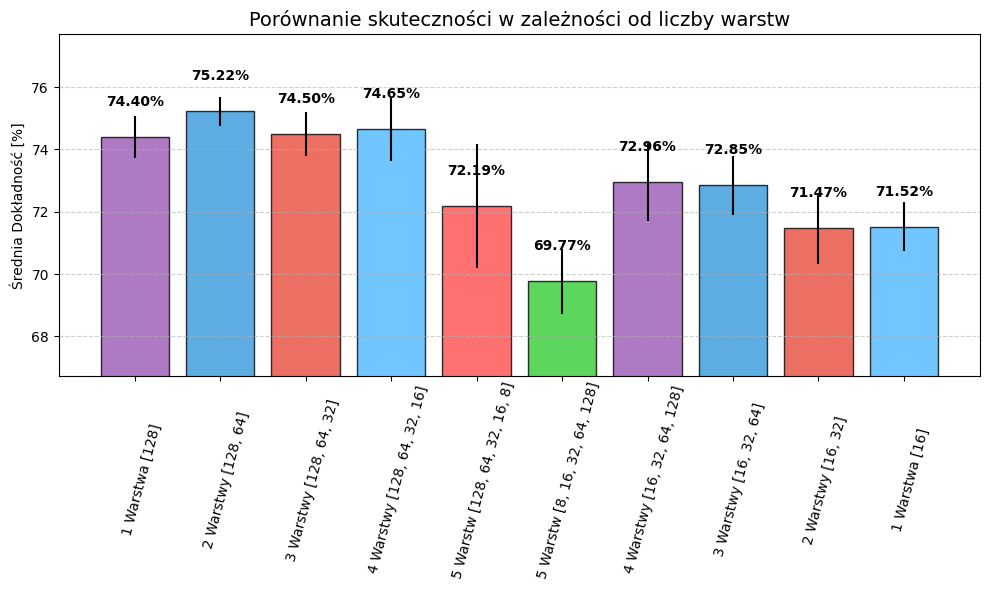

In [9]:
# ==================== GENEROWANIE WYKRESU ====================
plt.figure(figsize=(10, 6))
depth_means = [np.mean(depth_results[n]) for n in depth_configs.keys()]
std = [np.std(depth_results[n]) for n in depth_configs.keys()]
colors = ['#9b59b6', '#3498db', '#e74c3c', '#4db8ff', '#ff4d4d', '#33cc33']

# bars = plt.bar(depth_configs.keys(), depth_means, color=colors, alpha=0.8, edgecolor='black')
bars = plt.bar(depth_configs.keys(), depth_means, yerr = std ,color=colors, alpha=0.8, edgecolor='black')
plt.title('Porównanie skuteczności w zależności od liczby warstw', fontsize=14)
plt.ylabel('Średnia Dokładność [%]')
ymin = min([s-o for s, o in zip(depth_means, std)]) - 2
ymax = min(max([s+o for s, o in zip(depth_means, std)]) + 2, 102)
plt.ylim(ymin, ymax)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', fontweight='bold')

plt.xticks(rotation=75, ha='right', rotation_mode='anchor', horizontalalignment='center', verticalalignment='top')
plt.gca().tick_params(axis='x', pad=70) 
plt.tight_layout()
plt.show()

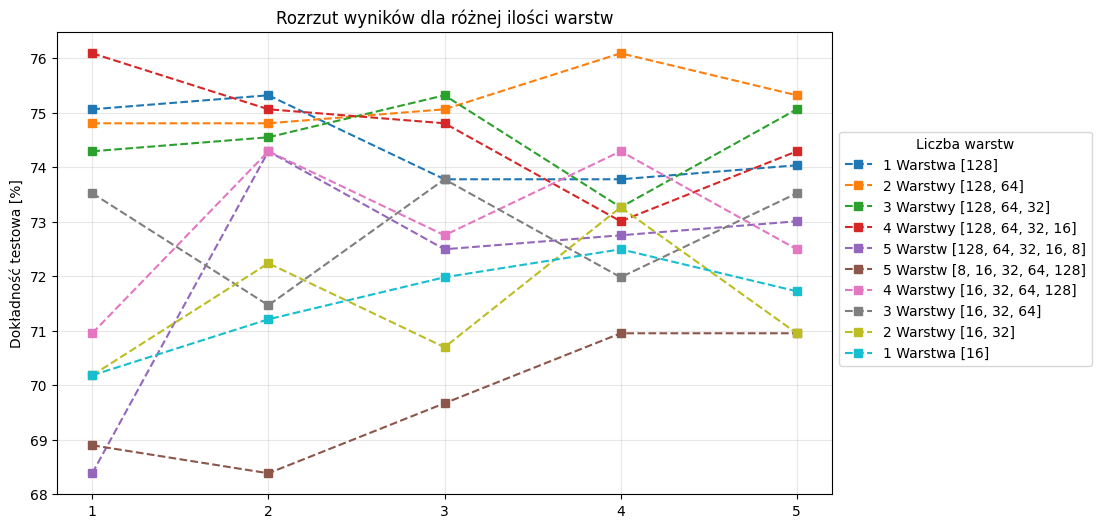

In [3]:
plt.figure(figsize=(10, 6))
for k2_val, accs in depth_results.items():
    plt.plot(range(1, num_repeats + 1), accs, marker='s', linestyle='--', label=f'{k2_val}')
plt.title('Rozrzut wyników dla różnej ilości warstw')
plt.xticks(range(1, num_repeats + 1))
plt.ylabel('Dokładność testowa [%]')
plt.legend(title="Liczba warstw", loc='upper left', bbox_to_anchor=(1, 0.8))
plt.grid(True, alpha=0.3)
plt.show()

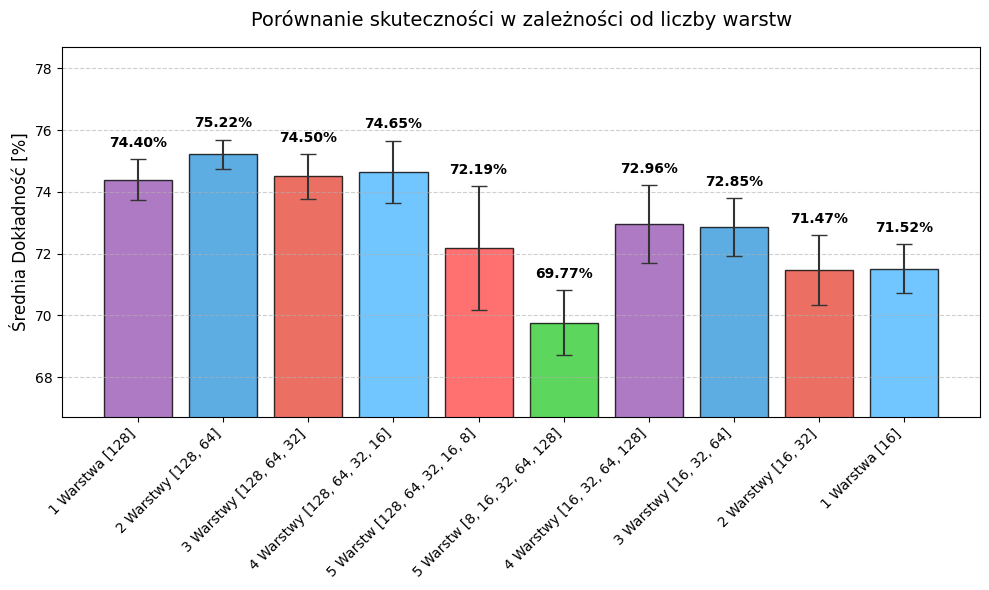

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ==================== GENEROWANIE WYKRESU ====================
plt.figure(figsize=(10, 6))

# 1. POPRAWKA: Zmiana np.mean na np.std
depth_keys = list(depth_configs.keys())
depth_means = [np.mean(depth_results[n]) for n in depth_keys]
std = [np.std(depth_results[n]) for n in depth_keys]  # Teraz liczy właściwe odchylenie!

colors = ['#9b59b6', '#3498db', '#e74c3c', '#4db8ff', '#ff4d4d', '#33cc33']

# 2. POPRAWKA: Tylko jedno wywołanie plt.bar z dodanym capsize
bars = plt.bar(
    depth_keys, 
    depth_means, 
    yerr=std, 
    color=colors, 
    alpha=0.8, 
    edgecolor='black',
    capsize=6,
    error_kw={'ecolor': '#333333', 'elinewidth': 1.5}
)

plt.title('Porównanie skuteczności w zależności od liczby warstw', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)

# 3. Dynamiczne skalowanie osi Y (teraz zadziała idealnie, bo std jest poprawne)
ymin = min([s - o for s, o in zip(depth_means, std)]) - 2
ymax = max([s + o for s, o in zip(depth_means, std)]) + 3 # +3 daje ładny zapas od góry na tekst
plt.ylim(ymin, ymax)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# 4. POPRAWKA: Tekst umieszczony bezpiecznie nad wąsem błędu
for i, bar in enumerate(bars):
    yval = bar.get_height()
    current_std = std[i]
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + current_std + 0.3,  # Pozycja: szczyt słupka + długość wąsa + mały margines
        f'{yval:.2f}%', 
        ha='center', 
        va='bottom',
        fontweight='bold'
    )

# 5. POPRAWKA: Usunięty gigantyczny pad=70, zostawiony czysty obrót
plt.xticks(rotation=45, ha='right')  # 45 stopni zazwyczaj wygląda najczytelniej i zajmuje mniej miejsca

plt.tight_layout()
plt.show()